## 10.1 RLHF with PPO — from scratch (numpy only)
Notebook overview:
- Implement a tiny transformer-based language model (LM) backbone in numpy.
- Use a frozen backbone to emulate a pretrained SFT LM.
- Build a trainable policy head (linear) and a value head (linear) on top of the frozen backbone.
- Create a frozen reference policy (SFT) as an anchor for KL.
- Create a transformer-based reward model (frozen) that scores full completions.
- Perform rollouts by sampling completions from the behavior policy (pi_old).
- Compute per-token KL shaping rewards, add terminal reward from RM to last token.
- Compute returns and advantages, normalize advantages.
- Run PPO updates that update only the policy & value heads (easy, educational).
- Include policy (clipped surrogate) loss, value MSE loss, entropy bonus, and KL computations.
- Plot losses across epochs.

Notes:
- This is a pedagogical labsheet. For a production-grade RLHF implementation you'd want full backprop through the transformer backbone (requires autograd), distributed sampling, longer sequences, tokenization, proper data, and careful engineering.
- We keep parameter updates limited to the heads so the math/implementation remains readable while still covering the full RLHF pipeline.


##10.2  Imports and small RNG helper

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42) # Set a random seed for reproducibility of results

# tiny helpers
def softmax(logits, axis=-1):
    # Numerically stable softmax function to convert logits into probabilities
    # It subtracts the maximum logit value to prevent overflow during exponentiation
    x = logits - np.max(logits, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True) # Normalize to sum to 1

def log_softmax(logits, axis=-1):
    # Computes the log of the softmax probabilities
    s = softmax(logits, axis=axis)
    return np.log(s + 1e-12) # Add a small epsilon for numerical stability to avoid log(0)

print("Check: basic helpers loaded.")

Check: basic helpers loaded.


In [2]:
# Toy vocabulary and tokenizer (small, deterministic)
# We'll use integer tokens. <bos>=0, <eos>=1, others start at 2.
VOCAB = ['<bos>', '<eos>', 'I', 'like', 'cats', 'dogs', 'and', 'hate', 'bananas', '.'] # Define the vocabulary as a list of strings
V = len(VOCAB) # Get the size of the vocabulary
itos = {i:tok for i,tok in enumerate(VOCAB)} # Integer-to-string mapping (id to token string)
stoi = {tok:i for i,tok in enumerate(VOCAB)} # String-to-integer mapping (token string to id)

# Simple whitespace-based tokenizer for our toy vocabulary.
def tokenize(text):
    # Expects tokens to be space-separated and lowercase to match the vocabulary
    toks = text.strip().split() # Split the input text into individual tokens
    # Prepend <bos> token, map words to their IDs, default to '.' if not found, and append <eos>
    ids = [stoi['<bos>']] + [stoi.get(t, stoi['.']) for t in toks] + [stoi['<eos>']]
    return np.array(ids, dtype=np.int32) # Return the list of token IDs as a NumPy array

def detokenize(ids):
    # Converts a list of token IDs back into a human-readable string
    return ' '.join(itos[int(i)] for i in ids) # Join the token strings with spaces

In [3]:
# Quick test for tokenizer
print("Vocab size:", V) # Print the size of the vocabulary
print("tokenize: 'I like cats . ' ->", tokenize('I like cats .')) # Test the tokenize function
print("Check: tokenizer ready.")

Vocab size: 10
tokenize: 'I like cats . ' -> [0 2 3 4 9 1]
Check: tokenizer ready.


##10.3 Minimal Transformer backbone in numpy (small, readable)
We'll implement a single-block transformer backbone with learned embeddings & positional embeddings.

In [4]:
class LayerNorm:
    def __init__(self, dim, eps=1e-5):
        # Initialize Layer Normalization layer
        self.dim = dim # Feature dimension
        self.eps = eps # Epsilon for numerical stability
        self.gamma = np.ones(dim) # Learnable scaling parameter, initialized to ones
        self.beta = np.zeros(dim) # Learnable shifting parameter, initialized to zeros

    def __call__(self, x):
        # Forward pass for Layer Normalization
        # x: input tensor of shape (batch, seq, dim)
        mu = x.mean(axis=-1, keepdims=True) # Calculate mean across the feature dimension
        var = ((x - mu)**2).mean(axis=-1, keepdims=True) # Calculate variance across the feature dimension
        xhat = (x - mu) / np.sqrt(var + self.eps) # Normalize input
        return self.gamma * xhat + self.beta # Apply learnable scale and shift

class FeedForward:
    def __init__(self, dim, hidden):
        # Initialize Feed-Forward Network layer
        # dim: input/output dimension, hidden: dimension of the hidden layer
        # Weights initialized with Xavier/He-like initialization for better training stability
        self.w1 = np.random.randn(dim, hidden) / np.sqrt(dim) # Input to hidden weights
        self.b1 = np.zeros(hidden) # Bias for hidden layer
        self.w2 = np.random.randn(hidden, dim) / np.sqrt(hidden) # Hidden to output weights
        self.b2 = np.zeros(dim) # Bias for output layer

    def __call__(self, x):
        # Forward pass for Feed-Forward Network
        # x: input tensor of shape (..., dim)
        h = np.tanh(x @ self.w1 + self.b1) # First linear transformation followed by tanh activation
        out = h @ self.w2 + self.b2 # Second linear transformation
        return out

In [ ]:
class MultiHeadAttention:
    def __init__(self, dim, n_heads):
        # Initialize Multi-Head Attention layer
        # dim: input/output dimension, n_heads: number of attention heads
        assert dim % n_heads == 0 # Ensure dimension is divisible by number of heads
        self.dim = dim
        self.n_heads = n_heads
        self.d_head = dim // n_heads # Dimension of each head

        # Linear projections for Query (Q), Key (K), Value (V)
        k = 1/np.sqrt(dim) # Scaling factor for weight initialization
        self.wq = np.random.randn(dim, dim) * k # Weights for Query projection
        self.wk = np.random.randn(dim, dim) * k # Weights for Key projection
        self.wv = np.random.randn(dim, dim) * k # Weights for Value projection
        self.wo = np.random.randn(dim, dim) * k # Weights for output projection

    def split_heads(self, x):
        # Splits the input tensor into multiple heads
        # x: (batch, seq, dim) -> (batch, n_heads, seq, d_head)
        b,s,d = x.shape
        x = x.reshape(b,s,self.n_heads,self.d_head) # Reshape to (batch, seq, n_heads, d_head)
        return x.transpose(0,2,1,3) # Transpose to (batch, n_heads, seq, d_head)

    def combine_heads(self, x):
        # Combines the outputs from multiple heads back into a single tensor
        # x: (batch, n_heads, seq, d_head) -> (batch, seq, dim)
        b,nh,s,dh = x.shape
        x = x.transpose(0,2,1,3).reshape(b,s,nh*dh) # Transpose and reshape back to (batch, seq, dim)
        return x

    def __call__(self, x, mask=None):
        # Forward pass for Multi-Head Attention
        # x: input tensor of shape (batch, seq, dim)
        q = x @ self.wq # Project input to Query
        k = x @ self.wk # Project input to Key
        v = x @ self.wv # Project input to Value

        qh = self.split_heads(q) # Split Query into multiple heads
        kh = self.split_heads(k) # Split Key into multiple heads
        vh = self.split_heads(v) # Split Value into multiple heads

        # Scaled dot-product attention computation
        scores = qh @ kh.transpose(0,1,3,2) / np.sqrt(self.d_head) # Compute attention scores
        if mask is not None:
            scores = scores + (mask * -1e9) # Apply mask (e.g., for causality) by setting scores to a very small number
        attn = np.exp(scores - np.max(scores, axis=-1, keepdims=True)) # Apply softmax to scores for attention weights (numerically stable)
        attn = attn / np.sum(attn, axis=-1, keepdims=True)

        context = attn @ vh # Compute context vectors by weighting Values with attention weights
        combined = self.combine_heads(context) # Combine outputs from all heads
        out = combined @ self.wo # Final linear projection of combined context
        return out

class TinyTransformerBackbone:
    def __init__(self, vocab_size, seq_len, dim=32, n_heads=4, hidden=64):
        # Initialize the Tiny Transformer Backbone model
        # vocab_size: size of the vocabulary
        # seq_len: maximum sequence length the model can handle
        # dim: embedding dimension and model dimension
        # n_heads: number of attention heads
        # hidden: hidden dimension for the FeedForward network
        self.vocab_size = vocab_size
        self.seq_len = seq_len
        self.dim = dim

        # Learnable token embeddings
        self.emb = np.random.randn(vocab_size, dim) / np.sqrt(vocab_size)
        # Learnable positional embeddings
        self.pos_emb = np.random.randn(seq_len, dim) / np.sqrt(seq_len)

        # Transformer layers: LayerNorm, MultiHeadAttention, LayerNorm, FeedForward
        self.ln1 = LayerNorm(dim) # First Layer Normalization
        self.attn = MultiHeadAttention(dim, n_heads) # Multi-Head Attention layer
        self.ln2 = LayerNorm(dim) # Second Layer Normalization
        self.ff = FeedForward(dim, hidden) # Feed-Forward Network

    def forward(self, token_ids):
        # Forward pass for the transformer backbone
        # token_ids: input tensor of shape (batch, seq)
        b,s = token_ids.shape
        assert s <= self.seq_len # Ensure input sequence length does not exceed max_seq_len

        # Combine token embeddings and positional embeddings
        # Look up embeddings for the input token IDs
        # Add positional embeddings based on the sequence position
        x = self.emb[token_ids] + self.pos_emb[np.arange(s)]

        # One transformer block application
        # Apply Multi-Head Attention with a residual connection (x + ...)
        # LayerNorm is applied before attention
        x = x + self.attn(self.ln1(x))
        # Apply Feed-Forward Network with a residual connection
        # LayerNorm is applied before the feed-forward network
        x = x + self.ff(self.ln2(x))
        return x  # Return output of shape (batch, seq, dim)

In [6]:
# Small smoke test for the transformer backbone
# Create an instance of the TinyTransformerBackbone
backbone = TinyTransformerBackbone(V, seq_len=16)
# Tokenize a sample sentence and convert to a batch format (add batch dimension)
ids = np.array([tokenize('I like cats .')])
# Pass the token IDs through the backbone
out = backbone.forward(ids)
print('backbone output shape', out.shape) # Print the shape of the output tensor
print("Check: backbone OK.")

backbone output shape (1, 6, 32)
Check: backbone OK.


##10.4 Policy and value heads (linear layers).
 Policy head maps the last hidden state at each token to vocab logits.

In [7]:
class PolicyValueHeads:
    def __init__(self, hidden_dim, vocab_size):
        # Initialize policy and value heads
        # hidden_dim: dimension of the transformer backbone's output (input to heads)
        # vocab_size: size of the vocabulary (output dimension for policy head)

        # Policy head: maps hidden states to vocabulary logits
        self.w_policy = np.random.randn(hidden_dim, vocab_size) / np.sqrt(hidden_dim) # Weights for policy head
        self.b_policy = np.zeros(vocab_size) # Bias for policy head

        # Value head: maps hidden states to a scalar value
        self.w_value = np.random.randn(hidden_dim, 1) / np.sqrt(hidden_dim) # Weights for value head
        self.b_value = np.zeros(1) # Bias for value head

    def logits(self, hidden_states):
        # Computes policy logits from hidden states
        # hidden_states: (batch, seq, dim) -> logits (batch, seq, vocab)
        b,s,d = hidden_states.shape
        return hidden_states @ self.w_policy + self.b_policy # Linear transformation to get logits

    def values(self, hidden_states):
        # Computes scalar value for each token's hidden state
        # per-token scalar value (batch, seq)
        return (hidden_states @ self.w_value + self.b_value).squeeze(-1) # Linear transformation to get values, then squeeze last dimension

In [8]:
# Create shared frozen backbone and heads (policy heads are trainable), and a frozen reference head.
SEQ_LEN = 16 # Define the sequence length
backbone = TinyTransformerBackbone(V, seq_len=SEQ_LEN, dim=32) # Instantiate the transformer backbone
heads = PolicyValueHeads(hidden_dim=32, vocab_size=V) # Instantiate the policy and value heads

# Make a reference (SFT) head: a frozen copy of the initial policy head
import copy # Import the copy module for deep copying
ref_heads = copy.deepcopy(heads)  # Create a deep copy of the heads to serve as a frozen reference policy

# Snapshot (pi_old) will be a copy of current trainable heads at rollout time

print('policy logits shape test:')
ids = np.array([tokenize('I like cats .')]) # Tokenize a sample prompt
h = backbone.forward(ids) # Get hidden states from the backbone
logits = heads.logits(h) # Compute logits using the policy head
values = heads.values(h) # Compute values using the value head
print('logits', logits.shape, 'values', values.shape) # Print shapes of logits and values
print("Check: heads ready.")

policy logits shape test:
logits (1, 6, 10) values (1, 6)
Check: heads ready.


In [9]:
# Reward model: small transformer + pooling + MLP -> scalar per completion.
class RewardModel:
    def __init__(self, vocab_size, seq_len, dim=32):
        # Initialize the Reward Model
        # It uses a transformer backbone, followed by pooling and an MLP for scalar scoring
        self.backbone = TinyTransformerBackbone(vocab_size, seq_len, dim=dim) # Transformer backbone
        # Pooling layer weights and bias
        self.w_pool = np.random.randn(dim, dim) / np.sqrt(dim)
        self.b_pool = np.zeros(dim)
        # Output layer weights and bias (MLP to scalar score)
        self.w_out = np.random.randn(dim,1) / np.sqrt(dim)
        self.b_out = np.zeros(1)

    def score(self, token_ids):
        # Computes a scalar score for a given sequence of token IDs
        # token_ids: (batch, seq)
        h = self.backbone.forward(token_ids)  # Get hidden states from the transformer backbone (b,s,d)
        # Simple pooling: mean over tokens across the sequence dimension
        pooled = h.mean(axis=1) @ self.w_pool + self.b_pool # Average hidden states and apply linear transformation
        out = pooled @ self.w_out + self.b_out # Apply final linear transformation to get the score
        return out.squeeze(-1) # Remove the last dimension to get a batch of scalar scores

In [10]:
# Create a frozen reward model (random init acts as some preference function)
rm = RewardModel(V, seq_len=SEQ_LEN, dim=32) # Instantiate the RewardModel
# Test reward model with a sample sentence
ids = np.array([tokenize('I like cats .')])
print('reward score', rm.score(ids)) # Print the scalar reward score
print("Check: reward model ready.")

reward score [-1.0975872]
Check: reward model ready.


In [11]:
# Sampling utilities: sample tokens autoregressively from a policy defined by (backbone + heads)

def sample_completion(backbone, heads, prompt_ids, max_new_tokens=8, temp=1.0):
    # Samples a completion given a prompt, using the transformer backbone and policy heads
    # backbone: The transformer backbone model
    # heads: The policy heads (containing policy weights)
    # prompt_ids: 1D array of token IDs for the prompt (including <bos>)
    # max_new_tokens: Maximum number of new tokens to generate
    # temp: Sampling temperature (controls randomness)

    seq = list(prompt_ids) # Initialize the sequence with the prompt tokens
    for _ in range(max_new_tokens):
        # Get the most recent part of the sequence, truncated to SEQ_LEN, for context
        ids = np.array([seq[-SEQ_LEN:]])
        h = backbone.forward(ids) # Pass the context through the backbone to get hidden states
        logits = heads.logits(h)[0, -1] # Get logits for the last token's hidden state (output of policy head)
        probs = softmax(logits / temp) # Apply softmax with temperature to get probabilities
        next_tok = np.random.choice(len(probs), p=probs) # Sample the next token based on probabilities
        seq.append(int(next_tok)) # Add the sampled token to the sequence
        if next_tok == stoi['<eos>']: # Stop if the end-of-sequence token is generated
            break
    return np.array(seq, dtype=np.int32) # Return the completed sequence of token IDs

In [12]:
# Test sampling from reference policy
prompt = tokenize('I') # Tokenize a simple prompt
# Sample a completion using the backbone and the frozen reference heads
comp = sample_completion(backbone, ref_heads, prompt, max_new_tokens=6)
print('sampled:', detokenize(comp)) # Detokenize and print the sampled completion
print('Check: sampling works.')

sampled: <bos> I <eos> bananas <bos> cats . I I
Check: sampling works.


In [13]:
# Rollout function: uses pi_old (snapshot of heads) to generate completions and record per-token logs and ref logs

def rollout_batch(prompts, backbone, heads_old, ref_heads, rm, max_new_tokens=8, beta=0.02):
    # prompts: list of token arrays (without eos)
    batch_data = []
    for p in prompts:
        # sample completion from heads_old
        seq = list(p)
        logp_old_tokens = []
        logp_ref_tokens = []
        hidden_values = []
        for _ in range(max_new_tokens):
            ids = np.array([seq[-SEQ_LEN:]])
            h = backbone.forward(ids)
            logits_old = heads_old.logits(h)[0, -1]
            logits_ref = ref_heads.logits(h)[0, -1]
            probs_old = softmax(logits_old)
            probs_ref = softmax(logits_ref)
            tok = np.random.choice(len(probs_old), p=probs_old)
            logp_old = np.log(probs_old[tok] + 1e-12)
            logp_ref = np.log(probs_ref[tok] + 1e-12)
            seq.append(int(tok))
            logp_old_tokens.append(logp_old)
            logp_ref_tokens.append(logp_ref)
            # store value from current heads (no grad) for bootstrapping
            v = heads_old.values(h)[0, -1]
            hidden_values.append(float(v))
            if tok == stoi['<eos>']:
                break
        token_ids = np.array([seq[-SEQ_LEN:]])
        # terminal reward from reward model
        r_comp = float(rm.score(np.array([seq + [0]*(SEQ_LEN - len(seq))])[:, :SEQ_LEN])) if len(seq) <= SEQ_LEN else float(rm.score(np.array([seq[-SEQ_LEN:]])))
        # build per-token KL-shaped rewards
        rewards = [-beta * (lo - lr) for lo, lr in zip(logp_old_tokens, logp_ref_tokens)]
        if len(rewards) == 0:
            # if no tokens generated? rare, handle
            rewards = [0.0]
            hidden_values = [0.0]
        rewards[-1] += r_comp  # add terminal RM to last token
        # compute returns R_t = sum_{u=t}^T r_u
        T = len(rewards)
        returns = [sum(rewards[t:]) for t in range(T)]
        # advantages A_t = R_t - V(s_t)
        advantages = [ret - v for ret, v in zip(returns, hidden_values)]
        batch_data.append({
            'prompt': p,
            'tokens': np.array(seq),
            'logp_old': np.array(logp_old_tokens),
            'logp_ref': np.array(logp_ref_tokens),
            'returns': np.array(returns),
            'advantages': np.array(advantages),
            'values': np.array(hidden_values),
            'rewards': np.array(rewards)
        })
    return batch_data

In [14]:
# Quick rollout demo with two prompts
prompts = [tokenize('I'), tokenize('I like')] # Define sample prompts
heads_old = copy.deepcopy(heads)  # Create a snapshot of current heads to act as pi_old
# Perform a batch rollout
batch = rollout_batch(prompts, backbone, heads_old, ref_heads, rm, max_new_tokens=6, beta=0.02)
print('batch size', len(batch)) # Print the number of completions in the batch
print('example item keys', list(batch[0].keys())) # Print keys available in a single batch item
print('Check: rollout OK.')

batch size 2
example item keys ['prompt', 'tokens', 'logp_old', 'logp_ref', 'returns', 'advantages', 'values', 'rewards']
Check: rollout OK.


C:\Users\Sachit Vij\AppData\Local\Temp\ipykernel_22712\1823550224.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r_comp = float(rm.score(np.array([seq + [0]*(SEQ_LEN - len(seq))])[:, :SEQ_LEN])) if len(seq) <= SEQ_LEN else float(rm.score(np.array([seq[-SEQ_LEN:]])))


In [15]:
# PPO utilities: advantage normalization, minibatching, kl & entropy calculators

def normalize(x):
    # Normalizes a NumPy array to have zero mean and unit variance
    mu = x.mean() # Calculate mean
    std = x.std() + 1e-8 # Calculate standard deviation, add epsilon for stability
    return (x - mu) / std # Return normalized array

def compute_entropy_from_logits(logits):
    # Computes the entropy of a probability distribution derived from logits
    # logits: (vocab,)
    p = softmax(logits) # Convert logits to probabilities
    return -np.sum(p * np.log(p + 1e-12)) # Calculate entropy (negative sum of p * log(p))

# Flatten batch into per-token arrays (masking variable lengths)
def flatten_batch(batch_data):
    # Flattens the list of batch_data items (each corresponding to a completion) into single NumPy arrays
    # This prepares the data for minibatch training, treating each token step as an individual sample.
    # returns dict of arrays: tokens_packed, logp_old, logp_ref, returns, advantages, values, masks
    all_tokens = []
    all_logp_old = []
    all_logp_ref = []
    all_returns = []
    all_adv = []
    all_values = []
    all_masks = []
    for item in batch_data:
        L = len(item['logp_old']) # Length of the generated sequence (excluding prompt) for this item
        # Collect data for tokens, log probabilities, returns, advantages, values, and masks
        all_tokens.extend(item['tokens'][-L:])  # Take only the generated tokens (last L tokens)
        all_logp_old.extend(item['logp_old'])
        all_logp_ref.extend(item['logp_ref'])
        all_returns.extend(item['returns'])
        all_adv.extend(item['advantages'])
        all_values.extend(item['values'])
        all_masks.extend([1]*L) # Mask of 1s for all actual tokens

    # Convert collected lists to NumPy arrays
    return {
        'tokens': np.array(all_tokens, dtype=np.int32),
        'logp_old': np.array(all_logp_old, dtype=np.float32),
        'logp_ref': np.array(all_logp_ref, dtype=np.float32),
        'returns': np.array(all_returns, dtype=np.float32),
        'advantages': np.array(all_adv, dtype=np.float32),
        'values': np.array(all_values, dtype=np.float32),
        'masks': np.array(all_masks, dtype=np.float32) # Masks are not strictly used in current PPO_update, but are good for variable-length handling
    }

print('Check: PPO utilities defined.')

Check: PPO utilities defined.


In [16]:
# Simple Adam optimizer for numpy parameter dicts (only used to update linear heads)
class Adam:
    def __init__(self, params, lr=1e-3, betas=(0.9,0.999), eps=1e-8):
        # Initialize Adam optimizer
        # params: list of numpy arrays (these are the model parameters to be updated)
        self.params = params
        self.lr = lr # Learning rate
        self.b1 = betas[0] # Exponential decay rate for the first moment estimates
        self.b2 = betas[1] # Exponential decay rate for the second moment estimates
        self.eps = eps # Epsilon for numerical stability
        self.m = [np.zeros_like(p) for p in params] # First moment vector (momentum), initialized to zeros
        self.v = [np.zeros_like(p) for p in params] # Second moment vector (adaptive learning rates), initialized to zeros
        self.t = 0 # Time step (iteration counter)

    def step(self, grads):
        # Perform one optimization step using computed gradients
        self.t += 1 # Increment time step
        for i,p in enumerate(self.params):
            g = grads[i] # Get the gradient for the current parameter

            # Update biased first moment estimate
            self.m[i] = self.b1 * self.m[i] + (1 - self.b1) * g
            # Update biased second moment estimate
            self.v[i] = self.b2 * self.v[i] + (1 - self.b2) * (g * g)

            # Correct bias for first moment
            m_hat = self.m[i] / (1 - self.b1 ** self.t)
            # Correct bias for second moment
            v_hat = self.v[i] / (1 - self.b2 ** self.t)

            # Calculate parameter update
            update = self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
            p -= update # Apply the update to the parameter (in-place modification)

# We'll create optimizer for heads parameters
opt = Adam([heads.w_policy, heads.b_policy, heads.w_value, heads.b_value], lr=1e-3) # Instantiate Adam optimizer for policy and value head parameters

print('Check: optimizer ready.')

Check: optimizer ready.


In [17]:
# PPO update step (updates only heads). This computes gradients for policy logits (linear head) and value head.

def ppo_update(batch_data, backbone, heads, ref_heads, opt, clip_eps=0.1, value_coef=1.0, ent_coef=0.01, kl_coef=0.0, epochs=4, minibatch_size=32):
    # Performs PPO updates on the policy and value heads
    # batch_data: Data collected from rollouts (list of dictionaries)
    # backbone: The transformer backbone (frozen)
    # heads: The current trainable policy and value heads
    # ref_heads: The frozen reference policy heads
    # opt: The Adam optimizer
    # clip_eps: PPO clipping parameter
    # value_coef: Coefficient for the value loss term
    # ent_coef: Coefficient for the entropy bonus term
    # kl_coef: Coefficient for the optional KL penalty to reference policy
    # epochs: Number of PPO epochs to run over the flattened batch
    # minibatch_size: Size of minibatches for gradient updates

    # Flatten the batch data into single arrays and normalize advantages
    flat = flatten_batch(batch_data)
    advs = normalize(flat['advantages']) # Normalize advantages to stabilize training
    returns = flat['returns']
    logp_old = flat['logp_old'] # Log probabilities from the behavior policy (pi_old)
    # logp_ref = flat['logp_ref'] # Not directly used in the loss, but used for logging KL if kl_coef > 0
    # masks = flat['masks'] # Not explicitly used here for masking variable length, but useful if implemented
    N = len(advs) # Total number of individual token-steps in the flattened batch

    losses = {'policy':[], 'value':[], 'entropy':[], 'total':[], 'kl':[]} # Dictionary to store loss history

    for ep in range(epochs):
        idxs = np.random.permutation(N) # Shuffle indices for minibatch sampling
        for start in range(0, N, minibatch_size):
            mb_idx = idxs[start:start+minibatch_size] # Get indices for current minibatch

            # Recompute logits and values under current policy (heads) for the minibatch
            # This approximation assumes each token's hidden state is obtained by running backbone on a sequence
            # consisting of that token only (prefixed by <bos>). This is a simplification for numpy-only.
            token_ids_mb = flat['tokens'][mb_idx] # Actual tokens sampled from the flattened batch
            seqs = np.stack([np.array([token_id]) for token_id in token_ids_mb]) # Create pseudo sequences for backbone input
            padded = np.zeros((len(seqs), SEQ_LEN), dtype=np.int32) # Pad sequences to SEQ_LEN
            padded[:,0] = stoi['<bos>'] # Set first token to <bos>
            padded[:,1] = seqs[:,0] # Set second token to the actual sampled token
            h = backbone.forward(padded) # Get hidden states from backbone
            last_hidden = h[:,1,:]  # Use hidden state at position 1 as representation for the sampled token

            # Compute logits and values for the current policy (heads)
            logits = last_hidden @ heads.w_policy + heads.b_policy  # Policy head output (mb, V)
            values_pred = (last_hidden @ heads.w_value + heads.b_value).squeeze(-1)  # Value head output (mb,)

            # Compute log probabilities under current policy
            logp = np.log(softmax(logits) + 1e-12) # Log probabilities for all possible next tokens
            tok_indices = token_ids_mb # The actual tokens that were sampled
            logp_curr = logp[np.arange(len(tok_indices)), tok_indices] # Log prob of *sampled* tokens under current policy

            # Calculate ratio: exp(logp_curr - logp_old)
            ratios = np.exp(logp_curr - logp_old[mb_idx]) # Probability ratio (pi_curr / pi_old)

            # Clipped surrogate loss for policy
            surr1 = ratios * advs[mb_idx] # Unclipped surrogate objective
            surr2 = np.clip(ratios, 1-clip_eps, 1+clip_eps) * advs[mb_idx] # Clipped surrogate objective
            policy_loss = -np.mean(np.minimum(surr1, surr2)) # PPO policy loss (negative, for gradient ascent)

            # Value loss (Mean Squared Error)
            value_loss = np.mean((values_pred - returns[mb_idx])**2) # MSE between predicted values and returns

            # Entropy bonus
            ent = np.mean([compute_entropy_from_logits(logits[i]) for i in range(len(logits))]) # Average entropy across minibatch
            entropy_loss = -ent * ent_coef # Entropy bonus (negative for gradient ascent, to maximize entropy)

            # Optional KL penalty to reference policy
            logp_ref_curr = np.log(softmax(last_hidden @ ref_heads.w_policy + ref_heads.b_policy) + 1e-12) # Log probs under ref policy
            kl = np.mean(np.sum(softmax(logits) * (logp - logp_ref_curr), axis=1)) # KL divergence (pi_curr || pi_ref)
            kl_loss = kl * kl_coef # KL penalty

            # Total loss for optimization
            total_loss = policy_loss + value_coef * value_loss + entropy_loss + kl_loss

            # Gradients computation
            # Policy head: grad_w_policy, grad_b_policy
            # Value head: grad_w_value, grad_b_value

            grad_w_policy = np.zeros_like(heads.w_policy)
            grad_b_policy = np.zeros_like(heads.b_policy)
            grad_w_value = np.zeros_like(heads.w_value)
            grad_b_value = np.zeros_like(heads.b_value)

            # Analytic gradient for value head (MSE loss)
            # d(value_loss)/d(values_pred) = 2*(values_pred - returns)/N_mb
            g_v = (2.0 * (values_pred - returns[mb_idx]) / len(values_pred)).reshape(-1,1)  # (mb,1)
            # d(value_loss)/d(w_value) = last_hidden.T @ g_v
            grad_w_value = last_hidden.T @ g_v
            # d(value_loss)/d(b_value) = sum(g_v)
            grad_b_value = g_v.sum(axis=0)

            # Numeric gradients for policy head (finite difference approximation)
            # This is slow but used for pedagogical purposes in numpy without autograd.
            eps = 1e-3 # Small epsilon for finite difference
            base_logits = logits.copy() # Baseline logits for comparison
            base_policy_loss = policy_loss # Baseline policy loss

            # Compute gradients for policy bias (b_policy)
            for i in range(base_logits.shape[1]): # Iterate through each output class (vocabulary size)
                b_orig = heads.b_policy[i] # Store original bias value
                heads.b_policy[i] = b_orig + eps # Perturb bias by epsilon

                # Recompute policy loss with perturbed bias
                logits_p = last_hidden @ heads.w_policy + heads.b_policy
                logp_p = np.log(softmax(logits_p) + 1e-12)
                logp_curr_p = logp_p[np.arange(len(tok_indices)), tok_indices]
                ratios_p = np.exp(logp_curr_p - logp_old[mb_idx])
                surr1p = ratios_p * advs[mb_idx]
                surr2p = np.clip(ratios_p, 1-clip_eps, 1+clip_eps) * advs[mb_idx]
                policy_loss_p = -np.mean(np.minimum(surr1p, surr2p))

                grad_b_policy[i] = (policy_loss_p - base_policy_loss) / eps # Estimate gradient
                heads.b_policy[i] = b_orig # Restore original bias value

            # Compute gradients for policy weights (w_policy)
            # Perturb each column of the weight matrix by epsilon to estimate gradient
            for j in range(heads.w_policy.shape[1]): # Iterate through each output class
                wcol_orig = heads.w_policy[:, j].copy() # Store original column of weights
                heads.w_policy[:, j] = wcol_orig + eps # Perturb column by epsilon

                # Recompute policy loss with perturbed weights
                logits_p = last_hidden @ heads.w_policy + heads.b_policy
                logp_p = np.log(softmax(logits_p) + 1e-12)
                logp_curr_p = logp_p[np.arange(len(tok_indices)), tok_indices]
                ratios_p = np.exp(logp_curr_p - logp_old[mb_idx])
                surr1p = ratios_p * advs[mb_idx]
                surr2p = np.clip(ratios_p, 1-clip_eps, 1+clip_eps) * advs[mb_idx]
                policy_loss_p = -np.mean(np.minimum(surr1p, surr2p))

                grad_w_policy[:, j] = (policy_loss_p - base_policy_loss) / eps # Estimate gradient
                heads.w_policy[:, j] = wcol_orig # Restore original weight column

            # Combine all computed gradients
            grads = [grad_w_policy, grad_b_policy, grad_w_value, grad_b_value]
            opt.step(grads) # Apply gradient updates using the optimizer

            # Record losses for monitoring
            losses['policy'].append(policy_loss)
            losses['value'].append(value_loss)
            losses['entropy'].append(ent)
            losses['total'].append(total_loss)
            losses['kl'].append(kl)
    return losses

print('Check: PPO update defined (note: uses finite-difference for policy grads — educational).')

Check: PPO update defined (note: uses finite-difference for policy grads — educational).


In [18]:
# Rollout function: uses pi_old (snapshot of heads) to generate completions and record per-token logs and ref logs

def rollout_batch(prompts, backbone, heads_old, ref_heads, rm, max_new_tokens=8, beta=0.02):
    # Performs rollouts (generates completions) for a batch of prompts and collects data for PPO.
    # prompts: list of token arrays (e.g., [tokenize('I'), tokenize('I like')])
    # backbone: The transformer backbone model
    # heads_old: A snapshot of the policy heads (behavior policy, pi_old)
    # ref_heads: The frozen reference policy heads (for KL divergence calculation)
    # rm: The Reward Model
    # max_new_tokens: Maximum number of new tokens to generate per completion
    # beta: KL divergence coefficient for reward shaping

    batch_data = [] # List to store data for each completion in the batch
    for p in prompts:
        # For each prompt, sample a completion from heads_old
        seq = list(p) # Initialize sequence with the prompt tokens
        logp_old_tokens = [] # Stores log probabilities of sampled tokens under pi_old
        logp_ref_tokens = [] # Stores log probabilities of sampled tokens under ref_heads
        hidden_values = [] # Stores value estimates for each generated token

        for _ in range(max_new_tokens):
            # Get the most recent part of the sequence (truncated to SEQ_LEN) for context
            ids = np.array([seq[-SEQ_LEN:]])
            h = backbone.forward(ids) # Get hidden states from the backbone
            logits_old = heads_old.logits(h)[0, -1] # Logits from pi_old for the last token
            logits_ref = ref_heads.logits(h)[0, -1] # Logits from ref_heads for the last token
            probs_old = softmax(logits_old) # Probabilities from pi_old
            probs_ref = softmax(logits_ref) # Probabilities from ref_heads

            tok = np.random.choice(len(probs_old), p=probs_old) # Sample next token from pi_old

            logp_old = np.log(probs_old[tok] + 1e-12) # Log probability of the sampled token under pi_old
            logp_ref = np.log(probs_ref[tok] + 1e-12) # Log probability of the sampled token under ref_heads

            seq.append(int(tok)) # Add sampled token to sequence
            logp_old_tokens.append(logp_old) # Store logp_old
            logp_ref_tokens.append(logp_ref) # Store logp_ref

            # Store value from current heads (pi_old) for bootstrapping (V(s_t) for advantage calculation)
            v = heads_old.values(h)[0, -1]
            hidden_values.append(float(v))

            if tok == stoi['<eos>']: # Stop if EOS token is generated
                break

        # Once completion is done, calculate terminal reward and KL-shaped rewards
        token_ids = np.array([seq[-SEQ_LEN:]]) # Get the full completed sequence (or its tail if longer than SEQ_LEN)
        # Terminal reward from the reward model (rm.score expects batch, seq)
        # Padding with <bos> if sequence is shorter than SEQ_LEN for consistent RM input
        r_comp = float(rm.score(np.array([seq + [0]*(SEQ_LEN - len(seq))])[:, :SEQ_LEN])) if len(seq) <= SEQ_LEN else float(rm.score(np.array([seq[-SEQ_LEN:]]))) # Reward from RM

        # Build per-token KL-shaped rewards
        # Each token's reward is -beta * KL divergence from pi_old to ref_heads at that step
        rewards = [-beta * (lo - lr) for lo, lr in zip(logp_old_tokens, logp_ref_tokens)]
        if len(rewards) == 0: # Handle cases where no new tokens were generated (e.g., prompt ends with <eos>)
            rewards = [0.0]
            hidden_values = [0.0]
        rewards[-1] += r_comp  # Add the terminal reward model score to the last token's reward

        # Compute returns R_t = sum_{u=t}^T r_u (sum of future rewards from time t)
        T = len(rewards)
        returns = [sum(rewards[t:]) for t in range(T)]

        # Advantages A_t = R_t - V(s_t) (how much better the actual return was than the predicted value)
        advantages = [ret - v for ret, v in zip(returns, hidden_values)]

        # Store all collected data for this completion
        batch_data.append({
            'prompt': p,
            'tokens': np.array(seq), # Full generated sequence
            'logp_old': np.array(logp_old_tokens), # Log probs under old policy
            'logp_ref': np.array(logp_ref_tokens), # Log probs under ref policy
            'returns': np.array(returns), # Discounted sum of rewards
            'advantages': np.array(advantages), # Advantage estimates
            'values': np.array(hidden_values), # Value estimates
            'rewards': np.array(rewards) # Per-token rewards
        })
    return batch_data

In [19]:
def train_rlhf(num_iterations=8, batch_prompts_per_iter=4, max_new_tokens=6):
    # Main training loop for RLHF
    # num_iterations: Number of outer RLHF iterations
    # batch_prompts_per_iter: Number of prompts to generate completions for in each iteration
    # max_new_tokens: Maximum tokens to generate per completion during rollouts

    training_logs = {'total_loss':[], 'policy_loss':[], 'value_loss':[], 'entropy':[], 'kl':[]} # Dictionary to store training logs
    for it in range(num_iterations):
        print('\n=== Iteration', it, '===') # Print current iteration number
        # Snapshot pi_old: Create a deep copy of the current trainable heads
        # This 'old' policy is used for rollouts and as the baseline for the PPO ratio.
        heads_old = copy.deepcopy(heads)

        # Create prompts for the current iteration
        # (Toy prompts 'I', 'I like', etc. are used for simplicity)
        prompts = [tokenize('I'), tokenize('I like'), tokenize('I'), tokenize('I like cats')][:batch_prompts_per_iter]

        # Perform rollouts to generate completions and collect data
        # Data includes sampled tokens, log probabilities, returns, and advantages.
        batch = rollout_batch(prompts, backbone, heads_old, ref_heads, rm, max_new_tokens=max_new_tokens, beta=0.02)

        # Run PPO updates using the collected batch data
        # Updates the trainable policy and value heads. Note the increased ent_coef to 0.1.
        losses = ppo_update(batch, backbone, heads, ref_heads, opt, clip_eps=0.2, value_coef=1.0, ent_coef=0.1, kl_coef=0.0, epochs=2, minibatch_size=16)

        # Log average losses for the current iteration
        training_logs['total_loss'].append(np.mean(losses['total']))
        training_logs['policy_loss'].append(np.mean(losses['policy']))
        training_logs['value_loss'].append(np.mean(losses['value']))
        training_logs['entropy'].append(np.mean(losses['entropy']))
        training_logs['kl'].append(np.mean(losses['kl']))
        print('avg total loss', training_logs['total_loss'][-1]) # Print the average total loss for the iteration
    return training_logs

# Start the RLHF training process
logs = train_rlhf(num_iterations=15, batch_prompts_per_iter=100, max_new_tokens=20)
print('Check: training finished.')


=== Iteration 0 ===
avg total loss 0.20715926945618

=== Iteration 1 ===
avg total loss 0.34237679460827036

=== Iteration 2 ===
avg total loss 0.23928621495068672

=== Iteration 3 ===
avg total loss 0.1759293039905649

=== Iteration 4 ===


C:\Users\Sachit Vij\AppData\Local\Temp\ipykernel_22712\302289834.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r_comp = float(rm.score(np.array([seq + [0]*(SEQ_LEN - len(seq))])[:, :SEQ_LEN])) if len(seq) <= SEQ_LEN else float(rm.score(np.array([seq[-SEQ_LEN:]]))) # Reward from RM


avg total loss 0.28279409570731007

=== Iteration 5 ===
avg total loss 0.13920151143143183

=== Iteration 6 ===
avg total loss 0.04390684037663293

=== Iteration 7 ===
avg total loss 0.25719369193885994

=== Iteration 8 ===
avg total loss -0.07290474238111096

=== Iteration 9 ===
avg total loss 0.18628841717189956

=== Iteration 10 ===
avg total loss 0.13772784841300176

=== Iteration 11 ===
avg total loss 0.41177379345634185

=== Iteration 12 ===
avg total loss 0.45028329191901056

=== Iteration 13 ===
avg total loss 0.15973434334945966

=== Iteration 14 ===
avg total loss -0.008882399328964258
Check: training finished.


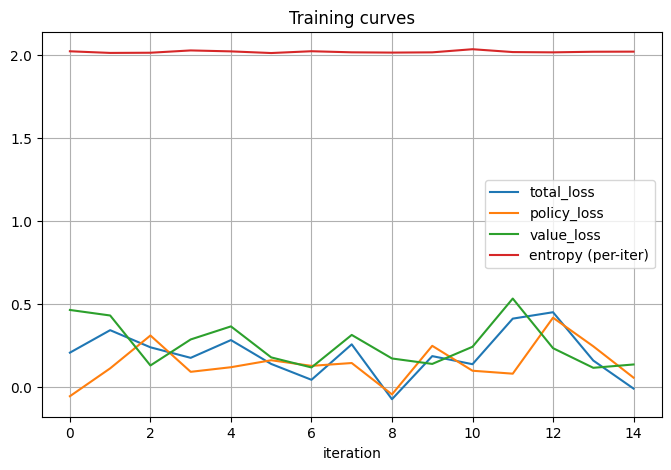

Check: plotted training curves.


In [20]:
# Plot loss curves to visualize training progress
plt.figure(figsize=(8,5)) # Create a figure with a specified size
plt.plot(logs['total_loss'], label='total_loss') # Plot total loss over iterations
plt.plot(logs['policy_loss'], label='policy_loss') # Plot policy loss over iterations
plt.plot(logs['value_loss'], label='value_loss') # Plot value loss over iterations
plt.plot(logs['entropy'], label='entropy (per-iter)') # Plot entropy over iterations
plt.title('Training curves') # Set plot title
plt.xlabel('iteration') # Set x-axis label
plt.legend() # Display legend for loss types
plt.grid(True) # Add a grid to the plot for better readability
plt.show() # Show the plot
print('Check: plotted training curves.')

In [21]:
# Quick evaluation: sample from updated policy vs reference policy
for prompt in [tokenize('I'), tokenize('I like')]: # Iterate through sample prompts
    print('PROMPT:', detokenize(prompt)) # Print the original prompt
    # Sample a completion using the frozen reference policy and print it
    print('REF :', detokenize(sample_completion(backbone, ref_heads, prompt, max_new_tokens=6)))
    # Sample a completion using the updated (trained) policy and print it
    print('POL :', detokenize(sample_completion(backbone, heads, prompt, max_new_tokens=6)))
    print() # Print a newline for separation
print('Check: end of labsheet.')

PROMPT: <bos> I <eos>
REF : <bos> I <eos> I I . <bos> dogs and
POL : <bos> I <eos> I I . cats and <bos>

PROMPT: <bos> I like <eos>
REF : <bos> I like <eos> <bos> I <bos> <eos>
POL : <bos> I like <eos> and <bos> <bos> <eos>

Check: end of labsheet.
